HKA Hauptkomponentenanalyse (Principal Component Analysis) der Federalist Papers

In [1]:
# Korpusdatei runterladen
import urllib.request
import urllib.error

url = "https://www.gutenberg.org/cache/epub/18/pg18.txt"

# Korpusdatei als federalist.txt runterladen
try:
    urllib.request.urlretrieve(url, "federalist.txt")
    print("Federalist Papiere Korpus erfolgreich heruntergeladen!")

# Fehlerhandlung
except urllib.error.URLError as fehler:
    print(f"Fehler beim Runterladen: {fehler}")

Federalist Papiere Korpus erfolgreich heruntergeladen!


Anzahl der Papiere gefunden: 85
Gespeichert: federalist_papers/federalist_01.txt
Gespeichert: federalist_papers/federalist_02.txt
Gespeichert: federalist_papers/federalist_03.txt
Gespeichert: federalist_papers/federalist_04.txt
Gespeichert: federalist_papers/federalist_05.txt
Gespeichert: federalist_papers/federalist_06.txt
Gespeichert: federalist_papers/federalist_07.txt
Gespeichert: federalist_papers/federalist_08.txt
Gespeichert: federalist_papers/federalist_09.txt
Gespeichert: federalist_papers/federalist_10.txt
Gespeichert: federalist_papers/federalist_11.txt
Gespeichert: federalist_papers/federalist_12.txt
Gespeichert: federalist_papers/federalist_13.txt
Gespeichert: federalist_papers/federalist_14.txt
Gespeichert: federalist_papers/federalist_15.txt
Gespeichert: federalist_papers/federalist_16.txt
Gespeichert: federalist_papers/federalist_17.txt
Gespeichert: federalist_papers/federalist_18.txt
Gespeichert: federalist_papers/federalist_19.txt
Gespeichert: federalist_papers/federa

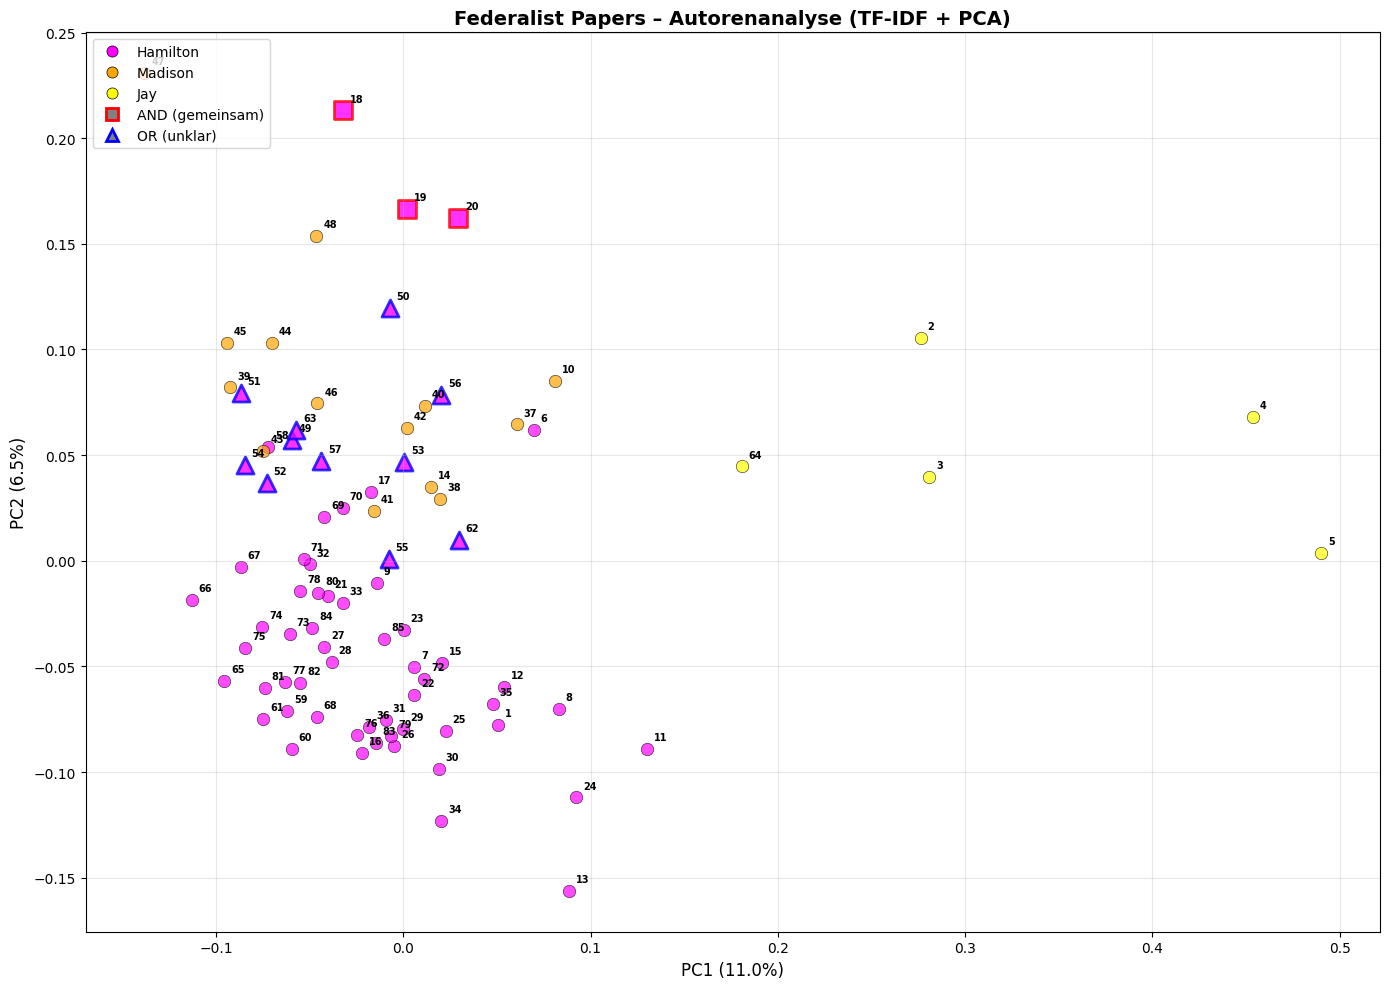

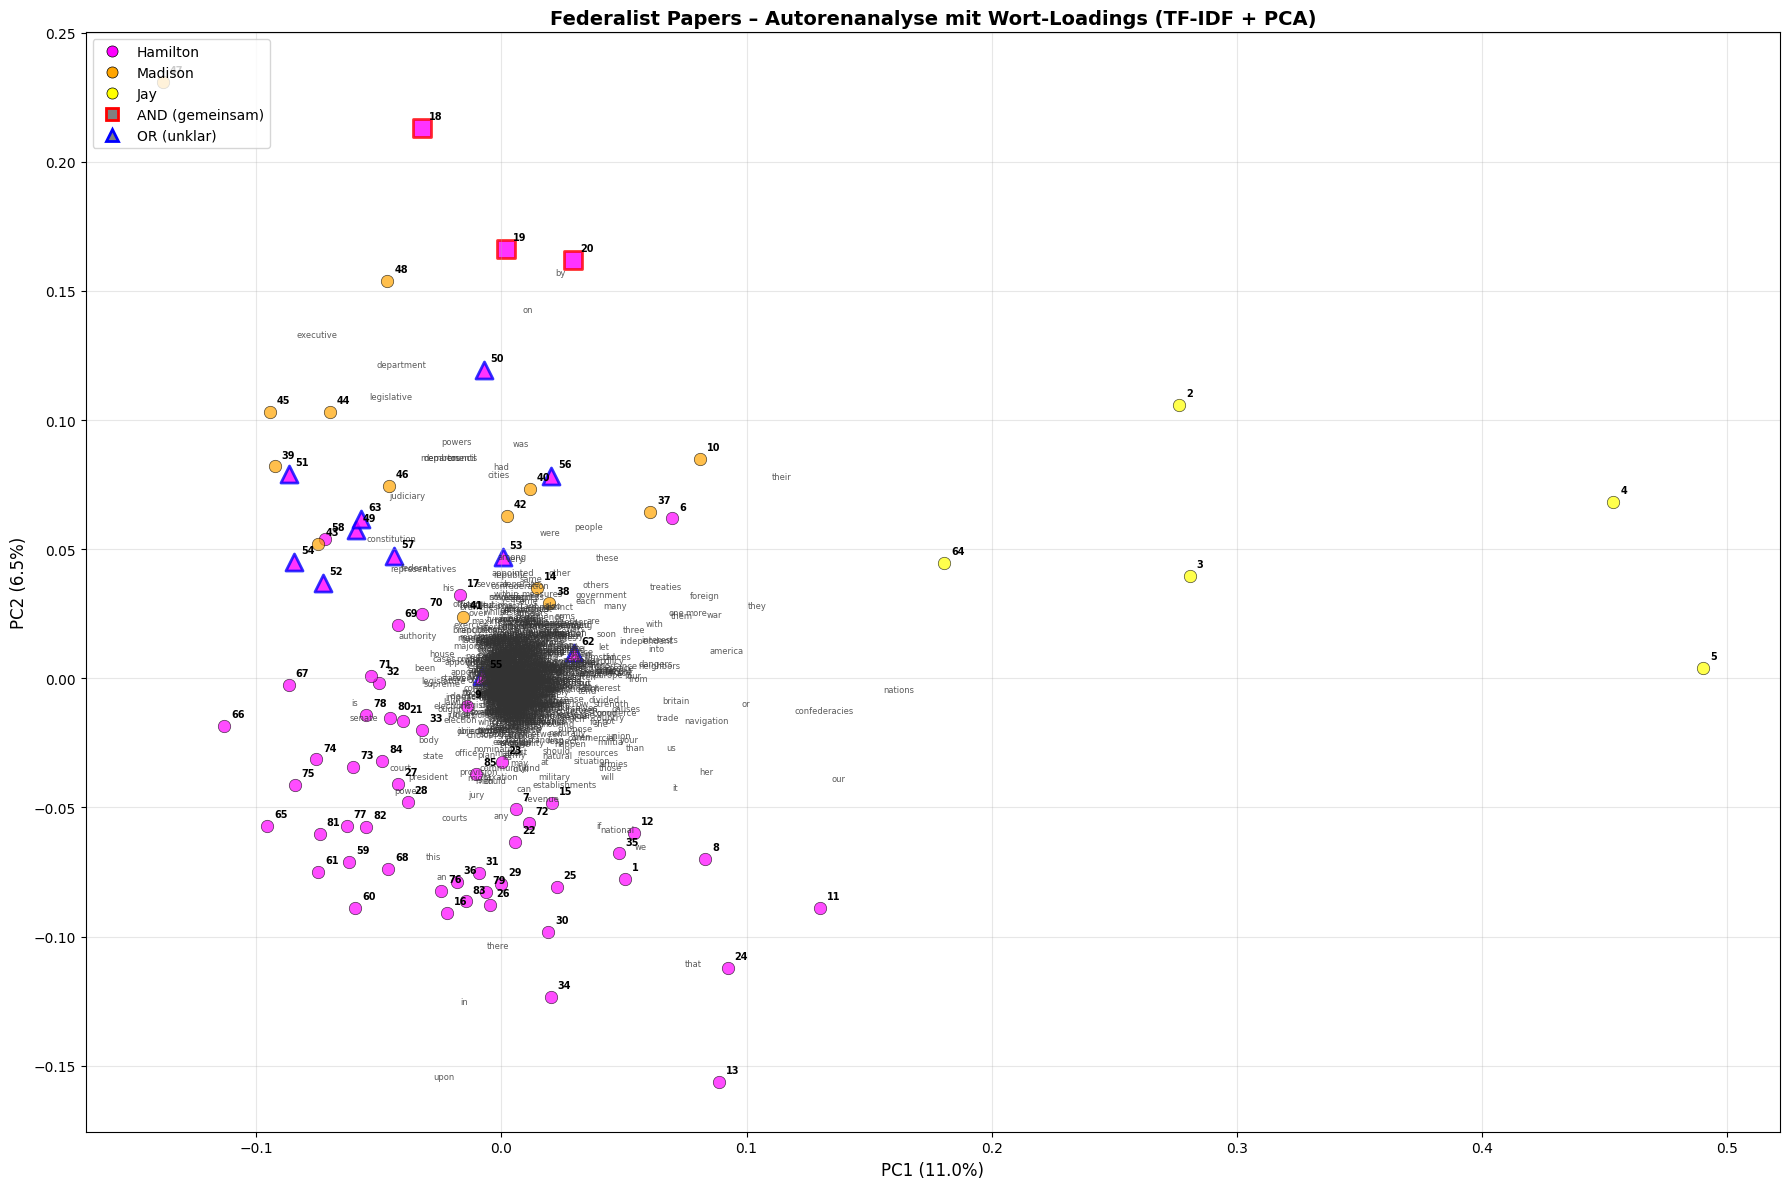

In [ ]:
# HKA Hauptkomponentenanalyse (Principal Component Analysis) der Federalist Papers
import re
import nltk
import os
from pandas import DataFrame
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Öffne die Textdatei
eingabedatei = open("federalist.txt", "r", encoding="utf8")
text = eingabedatei.read()
eingabedatei.close()

# Entferne den Projektgutenberg-Standard-Fußtext
text = re.sub(r'\*\*\* END OF THE PROJECT GUTENBERG.*', '', text, flags=re.DOTALL)

# Entferne die zweite Version von No. 70
text = re.sub(
    r'THE FEDERALIST\.\s+No\.\s+LXX\..*?\(There are two slightly different versions of No\. 70 included here\.\).*?(?=THE FEDERALIST\.\s+No\.|$)',
    '',
    text,
    flags=re.DOTALL
)

# Extrahiere alle Papiere mit Titel und Inhalt (nicht splitten!)
papiere = re.findall(
    r'THE FEDERALIST\.\s+No\.\s+[A-Z0-9]+\..*?(?=THE FEDERALIST\.\s+No\.|$)',
    text,
    re.DOTALL
)

print(f"Anzahl der Papiere gefunden: {len(papiere)}")

papier_nummern = [i + 1 for i in range(len(papiere))]

# Speichere jedes Papier als einzelne Datei
if not os.path.exists("federalist_papers"):
    os.makedirs("federalist_papers")

for i, papier_inhalt in enumerate(papiere):
    papier_nr = i + 1
    dateiname = f"federalist_papers/federalist_{papier_nr:02d}.txt"
    with open(dateiname, "w", encoding="utf8") as f:
        f.write(papier_inhalt)
    print(f"Gespeichert: {dateiname}")

# Erstelle ein Wörterbuch mit den Urheberschaftsinformationen
urheberschaft = {}
marker_typ = {}  # "AND", "OR", oder None für eindeutige

for i, papier_inhalt in enumerate(papiere):
    papier_nr = i + 1
    
    # Suche nach Autoren-Info in Großbuchstaben (z.B. "HAMILTON OR MADISON")
    autoren_match = re.search(
        r'(HAMILTON|MADISON|JAY)\s+(AND|OR)\s+(HAMILTON|MADISON|JAY)',
        papier_inhalt,
        re.IGNORECASE
    )
    
    if autoren_match:
        autor1 = autoren_match.group(1).capitalize()
        operator = autoren_match.group(2).upper()
        autor2 = autoren_match.group(3).capitalize()
        
        # Speichere den ersten Autor als Standardwert
        urheberschaft[str(papier_nr)] = autor1
        marker_typ[papier_nr] = operator
        print(f"No. {papier_nr}: {autor1} {operator} {autor2}")
    else:
        # Fallback auf die ursprüngliche Logik
        marker_typ[papier_nr] = None  # Eindeutig
        if papier_nr == 10 or papier_nr == 14 or (papier_nr >= 18 and papier_nr <= 20) or (papier_nr >= 37 and papier_nr <= 48):
            urheberschaft[str(papier_nr)] = "Madison"
        elif (papier_nr >= 2 and papier_nr <= 5) or papier_nr == 64:
            urheberschaft[str(papier_nr)] = "Jay"
        else:
            urheberschaft[str(papier_nr)] = "Hamilton"

# Farben und TF-IDF-Vektorisierung
autor_farben = {
    "Hamilton": "magenta",
    "Madison": "orange",
    "Jay": "yellow",
    "Unbekannt": "black"
}

tfidf_vektorisierer = TfidfVectorizer(max_features=1000, use_idf=True)
tfidf_matrix = tfidf_vektorisierer.fit_transform(papiere)
tfidf_matrix = tfidf_matrix.toarray()

# Führe PCA durch
pca = PCA(n_components=2)
meine_pca = pca.fit_transform(tfidf_matrix)

# Vorbereitung für die Klassifizierung
eindeutige_autoren = ["Hamilton", "Madison", "Jay"]
nummer_fuer_klasse = [i for i in range(len(eindeutige_autoren))]
autor_fuer_klassennummer = dict(zip(eindeutige_autoren, nummer_fuer_klasse))
text_klasse = np.array([autor_fuer_klassennummer.get(urheberschaft[str(f)], -1) for f in papier_nummern])
farben = [autor_farben[autor] for autor in eindeutige_autoren]

# ============================================================================
# PLOT 1: NUR PCA-DATENPUNKTE (ohne Wort-Wolke)
# ============================================================================
plt.figure(figsize=(14, 10))

# Zeichne die Punkte für eindeutige Autoren (kleine Kreise)
for farbe, klassennummer, autor in zip(farben, nummer_fuer_klasse, eindeutige_autoren):
    maske = text_klasse == klassennummer
    # Nur eindeutige Punkte (wo marker_typ None ist)
    eindeutige_maske = np.array([marker_typ.get(papier_nummern[j], None) is None for j in range(len(papier_nummern))])
    kombinierte_maske = maske & eindeutige_maske
    
    plt.scatter(
        meine_pca[kombinierte_maske, 0],
        meine_pca[kombinierte_maske, 1],
        label=autor,
        c=farbe,
        s=80,
        alpha=0.7,
        marker='o',
        edgecolors='black',
        linewidth=0.5
    )

# Markiere unsichere Papiere: AND = Quadrat, OR = Dreieck
for papier_nr in range(1, len(papier_nummern) + 1):
    if papier_nr in marker_typ and marker_typ[papier_nr] is not None:
        idx = papier_nr - 1
        autor = urheberschaft[str(papier_nr)]
        farbe = autor_farben[autor]
        operator = marker_typ[papier_nr]
        
        if operator == "AND":
            # Quadrat für AND
            plt.scatter(
                meine_pca[idx, 0],
                meine_pca[idx, 1],
                marker='s',
                c=farbe,
                s=150,
                edgecolors='red',
                linewidth=2,
                alpha=0.8
            )
        elif operator == "OR":
            # Dreieck für OR
            plt.scatter(
                meine_pca[idx, 0],
                meine_pca[idx, 1],
                marker='^',
                c=farbe,
                s=150,
                edgecolors='blue',
                linewidth=2,
                alpha=0.8
            )

# Beschrifte die Punkte mit den Papier-Nummern (versetzt)
for nummer, datenpunkt in zip(papier_nummern, meine_pca):
    plt.annotate(
        str(nummer),
        xy=datenpunkt,
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=7,
        fontweight='bold',
        ha='left',
        va='bottom'
    )

# Legende mit Markern
handles, labels = plt.gca().get_legend_handles_labels()
# Füge Legend-Einträge für AND und OR hinzu
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='magenta', markersize=8, label='Hamilton', markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8, label='Madison', markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=8, label='Jay', markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=8, label='AND (gemeinsam)', markeredgecolor='red', markeredgewidth=2),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=8, label='OR (unklar)', markeredgecolor='blue', markeredgewidth=2),
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.title("Federalist Papers – Autorenanalyse (TF-IDF + PCA)", fontsize=14, fontweight='bold')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# PLOT 2: PCA-DATENPUNKTE + WORT-WOLKE (Component Loadings)
# ============================================================================
plt.figure(figsize=(18, 12))

# Zeichne die Punkte für eindeutige Autoren (kleine Kreise)
for farbe, klassennummer, autor in zip(farben, nummer_fuer_klasse, eindeutige_autoren):
    maske = text_klasse == klassennummer
    # Nur eindeutige Punkte (wo marker_typ None ist)
    eindeutige_maske = np.array([marker_typ.get(papier_nummern[j], None) is None for j in range(len(papier_nummern))])
    kombinierte_maske = maske & eindeutige_maske
    
    plt.scatter(
        meine_pca[kombinierte_maske, 0],
        meine_pca[kombinierte_maske, 1],
        label=autor,
        c=farbe,
        s=80,
        alpha=0.7,
        marker='o',
        edgecolors='black',
        linewidth=0.5
    )

# Markiere unsichere Papiere: AND = Quadrat, OR = Dreieck
for papier_nr in range(1, len(papier_nummern) + 1):
    if papier_nr in marker_typ and marker_typ[papier_nr] is not None:
        idx = papier_nr - 1
        autor = urheberschaft[str(papier_nr)]
        farbe = autor_farben[autor]
        operator = marker_typ[papier_nr]
        
        if operator == "AND":
            # Quadrat für AND
            plt.scatter(
                meine_pca[idx, 0],
                meine_pca[idx, 1],
                marker='s',
                c=farbe,
                s=150,
                edgecolors='red',
                linewidth=2,
                alpha=0.8
            )
        elif operator == "OR":
            # Dreieck für OR
            plt.scatter(
                meine_pca[idx, 0],
                meine_pca[idx, 1],
                marker='^',
                c=farbe,
                s=150,
                edgecolors='blue',
                linewidth=2,
                alpha=0.8
            )

# Hole die component loadings
loadings = pca.components_
# Hole das Vokabular aus dem Vektorisierer
vocabulary = tfidf_vektorisierer.get_feature_names_out()

# Beschrifte die Wörter mit ihren loadings (dunkler)
for i, word in enumerate(vocabulary):
    plt.annotate(
        word,
        xy=(loadings[0, i], loadings[1, i]),
        fontsize=6,
        alpha=0.8,
        color='#333333'
    )

# Beschrifte die Punkte mit den Papier-Nummern (versetzt)
for nummer, datenpunkt in zip(papier_nummern, meine_pca):
    plt.annotate(
        str(nummer),
        xy=datenpunkt,
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=7,
        fontweight='bold',
        ha='left',
        va='bottom'
    )

# Legende mit Markern
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='magenta', markersize=8, label='Hamilton', markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8, label='Madison', markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=8, label='Jay', markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=8, label='AND (gemeinsam)', markeredgecolor='red', markeredgewidth=2),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=8, label='OR (unklar)', markeredgecolor='blue', markeredgewidth=2),
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.title("Federalist Papers – Autorenanalyse mit Wort-Loadings (TF-IDF + PCA)", fontsize=14, fontweight='bold')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
